# ChemWorld-Bench ?????

?? notebook ??????????????trajectory logging?evaluation?verify ? leaderboard ????????????????? onboarding?????? benchmark paper artifact ???????

## 0. 准备

在项目根目录先安装本地包：

```bash
python -m pip install -e ".[dev]"
```

如果你从 `notebooks/` 目录打开本 notebook，下面的代码会自动识别项目根目录，并把输出写到 `runs/notebook_demo/`。

## Kernel Selection

Use the `Python (ChemWorld)` Jupyter kernel. It should point to this project interpreter:

```text
D:\\Projects\\ChemWorld\\.venv\\Scripts\\python.exe
```

If you see `ModuleNotFoundError: No module named 'gymnasium'`, the notebook is using the wrong kernel. From the project root, run:

```bash
python -m pip install -e ".[dev,notebooks]"
python -m ipykernel install --user --name chemworld --display-name "Python (ChemWorld)"
```

Then switch Jupyter to `Python (ChemWorld)`.


In [1]:
import sys
from pathlib import Path

print("Python executable:", sys.executable)
print("Working directory:", Path.cwd())

try:
    import gymnasium  # noqa: F401
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "The active Jupyter kernel does not have ChemWorld dependencies installed. "
        "Select the kernel backed by .venv, or run: "
        "python -m pip install -e '.[dev,notebooks]' && "
        "python -m ipykernel install --user --name chemworld --display-name 'Python (ChemWorld)'"
    ) from exc

Python executable: D:\Projects\ChemWorld\.venv\Scripts\python.exe
Working directory: D:\Projects\ChemWorld\notebooks


In [2]:
import json
from pathlib import Path

import gymnasium as gym
import pandas as pd

import chemworld  # registers ChemWorld
from chemworld.agents.llm import ReplayLLMAgent
from chemworld.data.logging import load_jsonl
from chemworld.eval.leaderboard import aggregate_leaderboard
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.runner import make_agent, run_agent
from chemworld.eval.suite import run_suite
from chemworld.eval.verify import verify_records

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
OUTPUT_DIR = ROOT / "runs" / "notebook_demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("chemworld version:", chemworld.__version__)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

chemworld version: 0.1.0
project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\notebook_demo


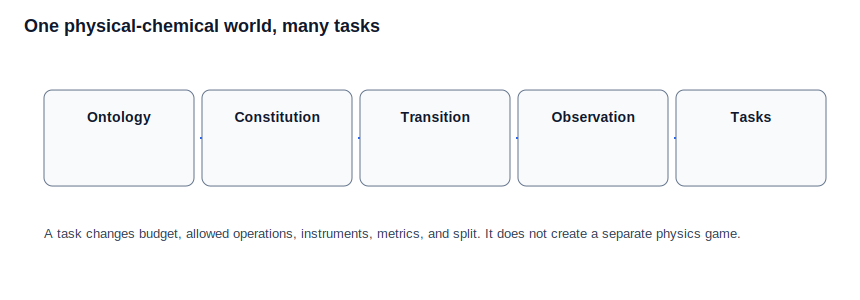

In [3]:
import importlib

from IPython.display import display

sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))
tu = importlib.import_module("tutorial_utils")

tu.display_project_canvas(
    title="End-to-end benchmark workflow",
    problem=(
        "Can an external researcher reproduce one ChemWorld experiment from "
        "config, seed, trajectory, and commit?"
    ),
    strategy=(
        "Run one manual event sequence, then compare baseline agents through "
        "the local suite runner."
    ),
    artifact="Trajectory JSONL, metrics JSON, replay verification report, and leaderboard row.",
    risks="Do not treat public-placeholder private runs as production hidden evaluation.",
)
display(tu.world_law_svg())


## 1. 初始化环境

`ChemWorld` 是当前唯一公开环境。每一步都是一个实验操作，例如 `add_solvent`、`heat`、`measure`，而不是一次性黑箱函数调用。

In [4]:
env = gym.make(
    "ChemWorld",
    world_split="public-dev",
    budget=8,
    objective="balanced",
    seed=42,
)

obs, task_info = env.reset(seed=42)
task_summary = {
    "env_id": task_info["env_id"],
    "world_id": task_info["world_id"],
    "world_split": task_info["world_split"],
    "objective": task_info["objective"],
    "budget": task_info["budget"],
    "world_family_version": task_info["world_family_version"],
}
task_summary

{'env_id': 'ChemWorld',
 'world_id': 'ChemWorld:public-dev:public:seed-42',
 'world_split': 'public-dev',
 'objective': 'balanced',
 'budget': 8,
 'world_family_version': 'chemworld-physical-chemistry'}

In [5]:
pd.DataFrame(task_info["operations"])[["id", "name", "required_fields", "preconditions"]]

,id,name,required_fields,preconditions
0,add_reagent,Add reagent,[amount_mol],[not_terminated]
1,add_solvent,Add solvent,"[volume_L, solvent]",[not_terminated]
2,add_catalyst,Add catalyst,"[catalyst_amount_mol, catalyst]",[not_terminated]
3,heat,Heat,"[target_temperature_K, duration_s, stirring_sp...","[has_volume, has_material]"
4,wait,Wait,"[duration_s, stirring_speed_rpm]","[has_volume, has_material]"
5,sample,Sample,[sample_volume_L],[has_volume]
6,quench,Quench,[],[has_volume]
7,add_phase,Add phase,"[phase, volume_L]",[not_terminated]
8,add_extractant,Add extractant,"[extractant, volume_L]","[has_volume, has_material, not_terminated]"
9,mix,Mix phases,"[duration_s, stirring_speed_rpm]",[has_phase_system]


In [6]:
instrument_rows = []
for instrument_id, spec in task_info["instruments"].items():
    instrument_rows.append(
        {
            "id": instrument_id,
            "name": spec["name"],
            "observable_keys": ", ".join(spec["observable_keys"]),
            "cost": spec["cost"],
            "sample_volume_L": spec["sample_volume_L"],
            "requires_terminated": spec["requires_terminated"],
        }
    )

pd.DataFrame(instrument_rows)

,id,name,observable_keys,cost,sample_volume_L,requires_terminated
0,hplc,HPLC,"yield, selectivity, byproduct_signal, purity, ...",0.080,0.00020,False
1,gc,GC,"byproduct_signal, degradation_warning",0.060,0.00015,False
2,uvvis,UV-vis,"yield, conversion, phase_ratio",0.025,0.00005,False
3,final_assay,Final assay,"yield, selectivity, conversion, byproduct_sign...",0.160,0.00030,True


## 2. 查看 Physical Constitution

每个环境状态和观测都要通过可执行 constitution 检查。这里展示的是初始状态的 checklist。

In [7]:
constitution = env.unwrapped.constitution_summary()
print("passed:", constitution["passed"])
print("rules:")
for rule in constitution["rules"]:
    print("-", rule)

constitution_checks = pd.DataFrame(constitution["checks"])
env.close()
constitution_checks.head(12)

passed: True
rules:
- material_conservation
- nonnegative_state
- unit_consistency
- yield_upper_bound
- energy_balance
- phase_mass_balance
- observation_non_omniscient
- measurement_has_cost
- action_preconditions
- safety_constraints
- public_private_reproducibility


,name,passed,message,value,tolerance
0,nonnegative:amount:A,True,amount:A=0.0,0.00,5.000000e-07
1,nonnegative:amount:P,True,amount:P=0.0,0.00,5.000000e-07
2,nonnegative:amount:B,True,amount:B=0.0,0.00,5.000000e-07
3,nonnegative:amount:D,True,amount:D=0.0,0.00,5.000000e-07
4,nonnegative:amount:E,True,amount:E=0.0,0.00,5.000000e-07
5,nonnegative:amount:Cat_active,True,amount:Cat_active=0.0,0.00,5.000000e-07
6,nonnegative:amount:Cat_dead,True,amount:Cat_dead=0.0,0.00,5.000000e-07
7,nonnegative:volume_L,True,volume_L=0.0,0.00,5.000000e-07
8,nonnegative:temperature_K,True,temperature_K=298.15,298.15,5.000000e-07
9,nonnegative:pressure_Pa,True,pressure_Pa=101325.0,101325.00,5.000000e-07


## 3. 手写一个实验事件序列

下面是一条完整实验流程：加溶剂、加反应物、加催化剂、升温反应、HPLC 中间测量、等待、终止、最终检测。

In [8]:
manual_actions = [
    {"operation": "add_solvent", "volume_L": 0.030, "solvent": 2},
    {"operation": "add_reagent", "amount_mol": 0.010},
    {"operation": "add_catalyst", "catalyst_amount_mol": 0.00025, "catalyst": 1},
    {
        "operation": "heat",
        "target_temperature_K": 388.0,
        "duration_s": 1500.0,
        "stirring_speed_rpm": 720.0,
    },
    {"operation": "measure", "instrument": "hplc"},
    {"operation": "wait", "duration_s": 600.0, "stirring_speed_rpm": 720.0},
    {"operation": "terminate"},
    {"operation": "measure", "instrument": "final_assay"},
]

manual_env = gym.make(
    "ChemWorld",
    world_split="public-dev",
    budget=len(manual_actions),
    seed=7,
)
manual_env.reset(seed=7)

manual_rows = []
for action in manual_actions:
    observation, reward, terminated, truncated, info = manual_env.step(action)
    row = {
        "step": info["step"],
        "operation": info["operation_type"],
        "instrument": info["instrument"],
        "reward": reward,
        "reward_source": info.get("reward_source"),
        "observed_keys": ", ".join(info.get("observed_keys", [])),
        "leaderboard_score": info.get("leaderboard_score"),
        "yield": float(observation["yield"][0]),
        "selectivity": float(observation["selectivity"][0]),
        "conversion": float(observation["conversion"][0]),
        "cost": float(observation["cost"][0]),
        "risk": float(observation["safety_risk"][0]),
        "precondition_failed": info["constraint_flags"]["precondition_failed"],
        "constitution_failed": info["constraint_flags"]["constitution_failed"],
    }
    manual_rows.append(row)
    if terminated or truncated:
        break

manual_env.close()
pd.DataFrame(manual_rows)

,step,operation,instrument,reward,reward_source,observed_keys,leaderboard_score,yield,selectivity,conversion,cost,risk,precondition_failed,constitution_failed
0,1,add_solvent,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.038400,0.077722,False,False
1,2,add_reagent,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.068400,0.094183,False,False
2,3,add_catalyst,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.248400,0.094183,False,False
3,4,heat,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.260900,0.159320,False,False
4,5,measure,hplc,0.407855,instrument:hplc,"yield, selectivity, byproduct_signal, purity, ...",NaN,0.663306,0.668669,NaN,0.340900,0.159320,False,False
5,6,wait,None,0.419831,carried_observation_with_public_ledger,"yield, selectivity, byproduct_signal, purity, ...",NaN,0.663306,0.668669,NaN,0.342567,0.110416,False,False
6,7,terminate,None,0.419831,carried_observation_with_public_ledger,"yield, selectivity, byproduct_signal, purity, ...",NaN,0.663306,0.668669,NaN,0.342567,0.110416,False,False
7,8,measure,final_assay,0.440506,instrument:final_assay,"yield, selectivity, conversion, byproduct_sign...",0.440506,0.589143,0.595694,1.0,0.502567,0.110416,False,False


## 4. 运行 baseline 并写出 trajectory

`run_agent` 会调用 agent、执行环境、记录每一步 action/observation/reward/info。如果提供 `output_path`，它会写出标准 JSONL 轨迹。

In [9]:
trajectory_path = OUTPUT_DIR / "random_public_dev_seed11.jsonl"

history = run_agent(
    env_id="ChemWorld",
    agent=make_agent("random"),
    world_split="public-dev",
    budget=8,
    objective="balanced",
    seed=11,
    output_path=trajectory_path,
)

print("steps:", len(history))
print("trajectory:", trajectory_path)

steps: 8
trajectory: D:\Projects\ChemWorld\runs\notebook_demo\random_public_dev_seed11.jsonl


In [10]:
records = load_jsonl(trajectory_path)
trajectory_table = pd.DataFrame(
    {
        "step": record["step"],
        "operation": record["operation_type"],
        "instrument": record["instrument"],
        "reward": record["reward"],
        "reward_source": record.get("reward_source"),
        "observed_keys": ", ".join(record.get("observed_keys", [])),
        "leaderboard_score": record.get("leaderboard_score"),
        "yield": record["observation"]["yield"],
        "selectivity": record["observation"]["selectivity"],
        "conversion": record["observation"]["conversion"],
        "cost": record["observation"]["cost"],
        "risk": record["observation"]["safety_risk"],
        "unsafe": record["constraint_flags"].get("unsafe", False),
        "precondition_failed": record["constraint_flags"].get("precondition_failed", False),
    }
    for record in records
)
trajectory_table

,step,operation,instrument,reward,reward_source,observed_keys,leaderboard_score,yield,selectivity,conversion,cost,risk,unsafe,precondition_failed
0,1,add_solvent,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.018329,0.090322,False,False
1,2,add_reagent,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.056810,0.145957,False,False
2,3,add_catalyst,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.125151,0.145957,False,False
3,4,heat,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.144074,0.149749,False,False
4,5,wait,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.145448,0.147148,False,False
5,6,wait,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.150233,0.144574,False,False
6,7,terminate,None,0.000000,public_ledger_only,"cost, safety_risk, score",NaN,NaN,NaN,NaN,0.150233,0.144574,False,False
7,8,measure,final_assay,0.157586,instrument:final_assay,"yield, selectivity, conversion, byproduct_sign...",0.157586,0.182541,0.195977,1.0,0.310233,0.144574,False,False


## 5. 评估与重放验证

`evaluate_records` 给出 benchmark 指标；`verify_records` 重新执行记录中的动作，确认 observation/reward 可复现。

In [11]:
evaluation = evaluate_records(records)
pd.DataFrame([evaluation.to_dict()]).T.rename(columns={0: "value"})

,value
agent_name,random
env_id,ChemWorld
world_split,public-dev
seed,11
steps,8
final_best_score,0.157586
best_valid_score,0.157586
best_valid_yield,0.182541
area_under_best_score,0.019698
sample_efficiency_step,None


In [12]:
verification = verify_records(records)
verification.to_dict()

{'verified': True, 'checked_steps': 8, 'max_abs_error': 0.0, 'mismatches': []}

## 6. Mini Suite And Leaderboard

This cell runs a small local suite for demonstration. It includes both `public-test` and `private-eval`, so the leaderboard reports `public_private_gap`. Formal experiments should use more seeds, splits, and budget.


In [13]:
suite_results = []
for agent_name in ["random", "scripted_chemistry", "lhs"]:
    suite_results.extend(
        run_suite(
            agent_name=agent_name,
            env_id="ChemWorld",
            world_splits=["public-test", "private-eval"],
            seeds=[0, 1],
            budget=12,
            objective="balanced",
            output_dir=OUTPUT_DIR / "suite" / agent_name,
        )
    )

leaderboard = aggregate_leaderboard(suite_results)
pd.DataFrame(leaderboard)

,agent_name,world_split,runs,mean_total_score,std_total_score,sem_total_score,ci95_total_score_low,ci95_total_score_high,mean_performance,mean_safety_aware_score,public_private_gap,rank
0,latin_hypercube,private-eval,2,0.287947,0.068376,0.048349,0.193183,0.382711,0.374297,0.332441,-0.134501,1
1,scripted_chemistry,private-eval,2,0.187671,0.042141,0.029798,0.129266,0.246075,0.248076,0.227953,-0.025235,2
2,scripted_chemistry,public-test,2,0.162436,0.044746,0.031640,0.100421,0.224450,0.215430,0.195265,-0.025235,3
3,latin_hypercube,public-test,2,0.153445,0.041497,0.029343,0.095933,0.210957,0.204412,0.162508,-0.134501,4
4,random,private-eval,2,0.093525,0.083498,0.059042,0.000000,0.209248,0.219108,0.000000,-0.038474,5
5,random,public-test,2,0.055051,0.043410,0.030696,0.000000,0.115215,0.127034,0.000417,-0.038474,6


## 7. LLM replay agent 接入方式

核心包不依赖任何在线 LLM API。LLM 结果可以通过 JSONL replay 文件进入同一评测协议。Replay 文件里保存 LLM 规划出的 recipe 参数，agent 会自动展开为事件序列。

In [14]:
replay_path = OUTPUT_DIR / "llm_replay.jsonl"
replay_payload = {
    "temperature": 115.0,
    "time": 1.2,
    "initial_concentration": 0.7,
    "stirring_speed": 680.0,
    "catalyst": 1,
    "solvent": 2,
    "hypothesis": "moderate temperature should limit degradation",
    "rationale": "start with a balanced condition",
}
replay_path.write_text(json.dumps(replay_payload) + "\n", encoding="utf-8")

llm_history = run_agent(
    env_id="ChemWorld",
    agent=ReplayLLMAgent(replay_path),
    world_split="public-dev",
    budget=6,
    objective="balanced",
    seed=21,
)

pd.DataFrame(
    {
        "step": record.step,
        "operation": record.action["operation"],
        "reward": record.reward,
        "score": record.observation["score"],
    }
    for record in llm_history
)

,step,operation,reward,score
0,1,add_solvent,0.000000,0.000000
1,2,add_reagent,0.000000,0.000000
2,3,add_catalyst,0.000000,0.000000
3,4,heat,0.000000,0.000000
4,5,terminate,0.000000,0.000000
5,6,measure,0.203063,0.203063


## 8. 当前闭环已经具备什么

- 统一环境：`ChemWorld`。
- 统一动作接口：事件序列，而不是旧式黑箱 recipe。
- Foundation：ontology、state ledger、constitution、transition kernel、observation kernel。
- Benchmark：JSONL trajectory、metrics、verify、suite、leaderboard。
- Agent：random、scripted、LHS、BO、safe BO、LLM replay adapter。

下一步可以基于这个 notebook 扩展教学 notebook、论文 artifact notebook 或 baseline calibration notebook。

## Reading Check

Use these prompts after running the full workflow.

In [15]:
tu.display_reflection_box(
    [
        "Which fields are required to reproduce this run on another machine?",
        "Which part of the workflow is benchmark infrastructure rather than chemistry?",
        "What would need to move server-side before a real private leaderboard?",
    ]
)
